<a href="https://colab.research.google.com/github/SherifBoshra/emotion-detection/blob/main/emotion-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# 📂 Load & Explore the Data
# Upload your kaggle.json when prompted
from google.colab import files
files.upload()

# Move it to the right place so Kaggle CLI can find it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Now download the dataset directly
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d fer2013

print("✅ Dataset downloaded and unzipped!")




Saving kaggle.json to kaggle (4).json
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)
replace fer2013/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Dataset downloaded and unzipped!


In [ ]:
train_dir = 'fer2013/train'
test_dir = 'fer2013/test'

emotions = os.listdir(train_dir) # Bngeb el folders bta3t el sewar
emotions.sort() # Sort l asmy el folders bl tarteb abgady
print("Emotion classes found:", emotions) # Bn3ml print lel folders
print("Number of classes:", len(emotions))



Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


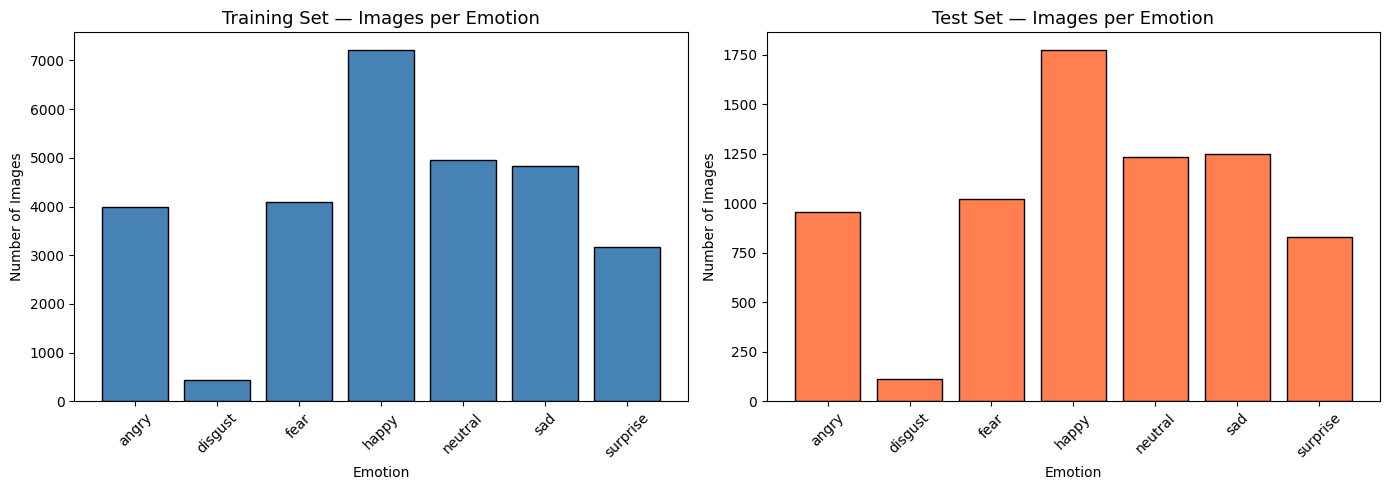

Training counts: 
angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171

Test counts: 
angry: 958
disgust: 111
fear: 1024
happy: 1774
neutral: 1233
sad: 1247
surprise: 831

Total: 28,709 training images
Total: 7,178  test images


In [ ]:
train_counts = {} #bracket fady ll train 3shan n3ed 3dadhom
test_counts = {} #bracket fady ll test 3shan n3ed 3dadhom

for emotion in emotions:
    train_counts[emotion] = len(os.listdir(os.path.join(train_dir, emotion))) #bn5aleh y3ed el length w y7sb el length bta3 kol emotion lwa7do
    test_counts[emotion] = len(os.listdir(os.path.join(test_dir, emotion)))


fig , axes = plt.subplots(1 , 2 , figsize = (14 , 5)) #bnplot figure n7ot 3aleh el data


axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue', edgecolor='black') #tafasel mlhash lazma bta3t el plot
axes[0].set_title('Training Set — Images per Emotion', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(test_counts.keys(), test_counts.values(), color='coral', edgecolor='black')
axes[1].set_title('Test Set — Images per Emotion', fontsize=13)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('results/class_distribution.png', dpi=150)  # save for GitHub
plt.show()



print("Training counts: ") # hena bn3ml print l kol emotion lwa7do w nshof 3dado
for emotion, count in train_counts.items():
    print(f"{emotion}: {count}")
print("\nTest counts: ")
for emotion, count in test_counts.items():
    print(f"{emotion}: {count}")

print(f"\nTotal: {sum(train_counts.values()):,} training images") # w dah el sum bta3hom 3la ba3d
print(f"Total: {sum(test_counts.values()):,}  test images")

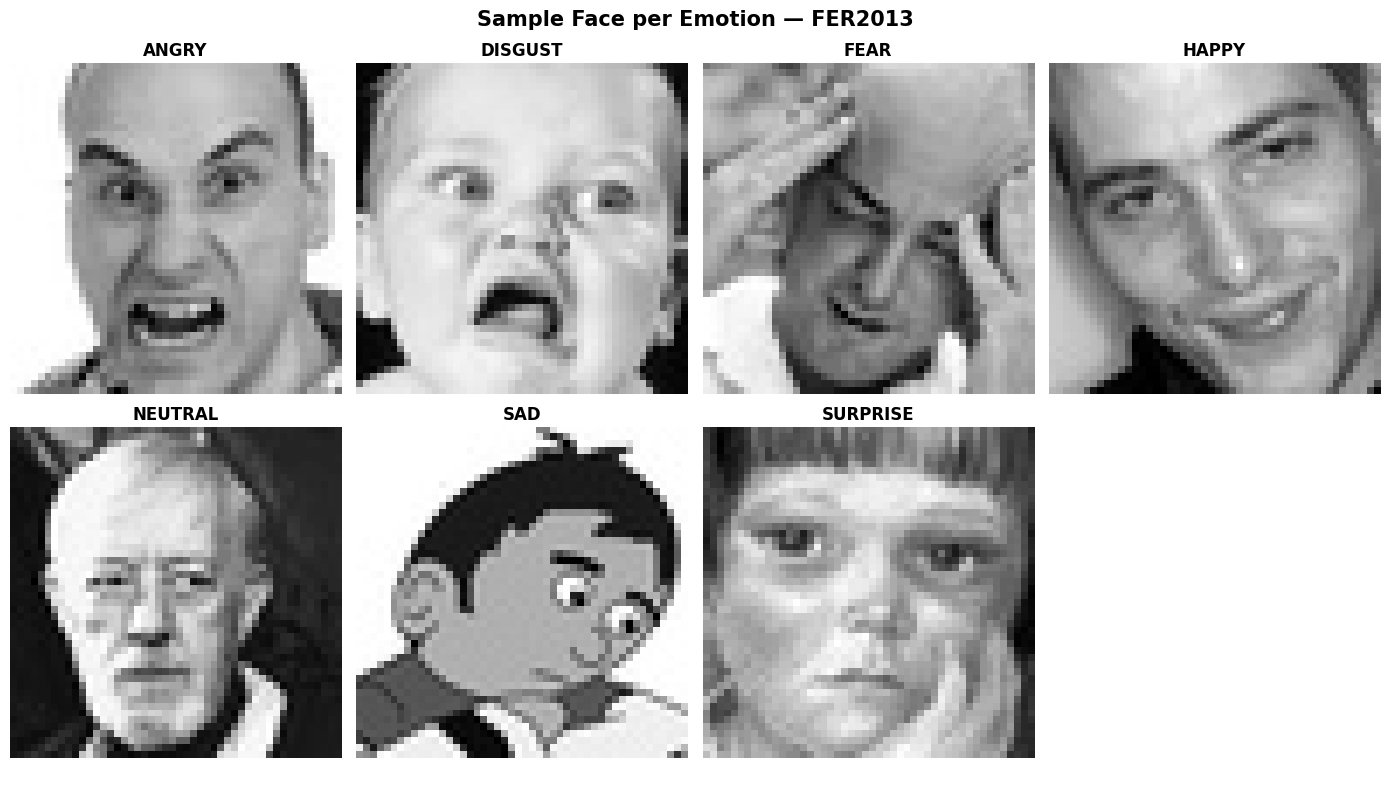

In [ ]:
fig , axes = plt.subplots(2 , 4 , figsize = (14 , 8)) # bn3ml plot n7ot 3aleh el emotions
axes = axes.flatten()


for i , emotion in enumerate(emotions): #bn3ml for loop 3shan n3ady 3la el emotions kolaha w ngeb awl sora f kol file
    img_path = os.path.join(train_dir , emotion , os.listdir(os.path.join(train_dir , emotion))[0])
    img = plt.imread(img_path)

    img = plt.imread(img_path) # hena 3shan y2ra el sora w y3mlaha plot
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(emotion.upper(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off') # bnshel el axes el tamna 3shan homa 7 emotions bas

plt.suptitle('Sample Face per Emotion — FER2013', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('results/sample_faces.png', dpi=150)  # save for GitHub
plt.show()

In [ ]:
# 🔧 Phase 2 — Preprocessing & Data Augmentation

IMG_SIZE = 48 # 7agm el sewar 48 x 48 pixel
BATCH_SIZE = 48 # kol magmo3t train hyb2o 64 sora
NUM_CLASSES = 7 # 3dad el emotions
EPOCHS = 30 # kam loop ht3ady 3la el dataset kolaha

COLOUR_MODE = 'grayscale' # 3mlnha gray scale 3shan el dataset gray lw kanet rgb kona hn8ayar hena


In [ ]:

train_datagen = ImageDataGenerator(
    rescale = 1./255, # bn5aly el 255 mn 0 l 1 normalization mn el a5er
    rotation_range=25,# bn5aleh ylef el sora 25 degree 3shan yshofha b shakl mo5talef w el accuracy t3la w el klam dah hytba2 3ala kol el ba2y eno bygarab 3shan y3aly el accuracy
    width_shift_range=0.15, # bnshift el sora ymen shmal b nsbet 15%
    height_shift_range=0.15,   # bnshift el sora fo2 ta7t b nsbet 15%
    horizontal_flip=True,     # bykleb el sora bl ganb
    zoom_range=0.15, # by3ml zoom in w out bnsbet 15%
)

test_datagen = ImageDataGenerator(
    rescale = 1./255 # bn3ml hena normalize bas
    #leh? 3shan e7na 3yzen yshof ashkal mo5talefa mn el emotions fl train 3shan yt3raf 3aleha kolaha bas fl test 3yzen el sewar tb2a a2rab ll 7a2e2a 3shan yt3lm sa7
)


In [ ]:

train_generator = train_datagen.flow_from_directory( # hena bn3ml load ll training data
        train_dir,
        target_size=(IMG_SIZE , IMG_SIZE), #bn7ot el hagat ely kona 3mlna zy 7agm el sora w el batch size w el colour mode
        batch_size=BATCH_SIZE,
        color_mode=COLOUR_MODE,
        class_mode='categorical', # hena bn3ml one hot encoding leh 3shan el model msh fahm y3ny eh happy w sad w angry w el klam dah fa lma sora btb2a happy bydeha value 1 w el ba2y 0 w hakza f kolo 3shan yfra2
        shuffle=True, # hena by8yar order el sewar kol train 3shan yfham a7san
        seed=42 # el random order bta3 el sewar byb2a howa howa kol mara lma nygy nsh8al el model 3shan lw mkansh keda hyb2a feh mshakel w leh 42 bzat 3shan dah standard el nas bt3mlo bas msh aktar
)

test_generator = test_datagen.flow_from_directory( # nafs el klam hena bas lltest bn3ml load
        test_dir,
        target_size=(IMG_SIZE , IMG_SIZE),
        batch_size=BATCH_SIZE,
        color_mode=COLOUR_MODE,
        class_mode='categorical',
        shuffle=False # hena leh el shuffle false 3shan l el test mo5talefa kol mara 3shan el evaluation bta3 el model yb2a howa howa kol mara

  )


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = list(train_generator.class_indices.values()) # hena bn3ml ll class labels mn 0 l 6
class_names = list(train_generator.class_indices.keys())

print("class mapping", train_generator.class_indices)

weights = compute_class_weight( # w hena bn3ml weights 3shan el classes ely el dataset bta3tha olayela zy el disgust bndelo ahamya aktar mn el ba2y fl training 3shan ytla3 el accuracy bta3to kwaisa

    class_weight = 'balanced',
    classes = np.array(class_labels),
    y = train_generator.classes
)

class_weights = dict(zip(class_labels, weights)) # w hena bn5aleh ygbha w y7otaha f dictionary


print("\n⚖️  Class Weights:")
for name, label in train_generator.class_indices.items():
    print(f"  {name:10s} (class {label}): {class_weights[label]:.4f}") # hena lma n3ml print hyban en el disgust 9.4 y3ny ahameto 9.4x el 3ady

class mapping {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

⚖️  Class Weights:
  angry      (class 0): 1.0266
  disgust    (class 1): 9.4066
  fear       (class 2): 1.0010
  happy      (class 3): 0.5684
  neutral    (class 4): 0.8260
  sad        (class 5): 0.8491
  surprise   (class 6): 1.2934


In [ ]:
# ── Sanity Check ─────────────────────────────────────────────
print("=" * 45)
print(f"  Training   → {train_generator.samples:,} images")
print(f"  Test       → {test_generator.samples:,} images")
print(f"  Batch size → {BATCH_SIZE}")
print(f"  Steps/epoch→ {train_generator.samples // BATCH_SIZE} batches")
print(f"  Image shape→ ({IMG_SIZE}, {IMG_SIZE}, 1)")  # 1 = grayscale channel
print("=" * 45)

# Peek at one batch to confirm shapes are right
images, labels = next(train_generator)
print(f"\n  One batch of images shape: {images.shape}")
print(f"  One batch of labels shape: {labels.shape}")
print(f"  Pixel value range: {images.min():.1f} → {images.max():.1f}  ✅ (should be 0.0 → 1.0)")

  Training   → 28,709 images
  Test       → 7,178 images
  Batch size → 48
  Steps/epoch→ 598 batches
  Image shape→ (48, 48, 1)

  One batch of images shape: (48, 48, 48, 1)
  One batch of labels shape: (48, 7)
  Pixel value range: 0.0 → 1.0  ✅ (should be 0.0 → 1.0)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, MaxPooling2D,
    Dropout, Flatten, Dense, Input
)
from tensorflow.keras.regularizers import l2

def build_emotion_model(input_shape = (48 , 48 , 1), num_classes = 7):
    model = Sequential(name = 'EmotionDetector')

    model.add(Input(shape = input_shape))
    # ── BLOCK 1 — Low-level features (edges, lines) ──────────
    model.add(Conv2D(32 , (3 , 3) , padding = 'same' , activation = 'relu')) # 32 layer w 3 x 3 pixels by3ml scan ll sora b 32 tary2a mo5talefa
    model.add(BatchNormalization()) # normalize el output

    model.add(Conv2D(32 , (3 , 3) , padding = 'same' , activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2 , 2)))
    # hena bn5aly el sewar ts8ar el nos 3shan keda (2 , 2) w leh 3shan n5aly el sewar tb2a dakeka aktar
    model.add(Dropout(0.25))
    #bn2fl 25% 3shwa2yan 3shan y5aly el ba2y ysht8al a7san w dah by5aly el overfitting my7salsh 3shan by5aleh my7fazsh el training yfhamo bas

    # ── BLOCK 2 — Mid-level features (eyes, nose, mouth) ─────
    model.add(Conv2D(64 , (3 , 3) , padding = 'same' , activation = 'relu')) # 64 layer bndawar 3ala sewar aktar 3shan ndwar 3ala patterns as3ab llswar
    model.add(BatchNormalization())

    model.add(Conv2D(64 , (3 , 3) , padding = 'same' , activation = 'relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size = (2 , 2))) # bns8ar el nos tany
    model.add(Dropout(0.25)) # nafs el by7sal fo2

    # ── BLOCK 3 — High-level features (emotion patterns) ───────────────
    model.add(Conv2D(128 , (3 , 3) , padding = 'same' , activation = 'relu')) # 128 layer 3shan complex aktar w bnt3raf 3la emotions el wesh
    model.add(BatchNormalization())

    model.add(Conv2D(128 , (3 , 3) , padding = 'same' , activation = 'relu'))
    model.add(BatchNormalization())

    model.add(MaxPooling2D(pool_size = (2 , 2)))
    model.add(Dropout(0.25))

    # ── CLASSIFIER HEAD ───────────────────────────────────────
    model.add(Flatten()) # 6 x 6 x 128 = 4608 values hnd5alha 3la el dense layer ely ta7t


    model.add(Dense(256 , activation = 'relu' , kernel_regularizer=l2(0.001))) # 256 layer 3shan dah aham goz2 fl model goz2 el classifier w 7aten 12 regularizer bn7ot penalty 3ala el weights el kbera (3shan n2alel el overfitting)
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    # 50% dropout 3n ely fo2 3shan deh aktar layer mohema fa lazm n2alel el arkam fl a5er khales

    model.add(Dense(num_classes , activation = 'softmax')) # bn3ml neurons 3la 3dad el classes w el softmax btedy values w el sum bta3thom 1 y3ny lw happy fa el value htb2a 0.87 w el ba2y olayel

    return model

model = build_emotion_model()
model.summary()




Model: "EmotionDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,470,951 (5.61 MB)

 Trainable params: 1,469,543 (5.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile (
    optimizer = Adam(learning_rate = 0.001), # adam optimizer byzbat el learning rate 3la 7asab el results
    loss = 'categorical_crossentropy', # dah byedy categories l el results y3ny lw 7elwa htb2a very good w lw we7sha htb2a very bad
    metrics = ['accuracy'] # 3shan tdeny nsbet el accuracy fl a5er
)

print("✅ Model compiled!")
print(f"\nTotal trainable parameters: {model.count_params():,}")

✅ Model compiled!

Total trainable parameters: 1,470,951


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping ,
    ReduceLROnPlateau ,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor = 'val_accuracy',   # nshof accuracy el validation
        patience = 10,      # bnwa2f el epoch lw mafesh ta7sen b3d 10 marat
        verbose = 1,        # verbose btl3 message kol ma haga leha 3laka bl goz2 dah y7sal
        restore_best_weights = True # bnrga3 hena l a7san version
    ),

    # hena bn3mla 3shan lw mafesh ta7son fl train

    ReduceLROnPlateau(
        monitor = 'val_loss',   # nshof el validation loss
        factor = 0.5,     #   hn2alel el learning rate el nos lma ys7al mshakel
        patience = 5,
        verbose = 1,
        min_lr = 1e-7     # bn2lesh 3n el learning rate 1e-6
    ),

    # lma el model ybatal yt7asen na5od 5atawat so8ayara


    ModelCheckpoint(
        filepath = 'best_emotion_model.h5',   # bnsave el location 3shan nrga3lo
        monitor = 'val_accuracy',
        save_best_only = True,  # bn3ml save lma a7san version train y7sal
        verbose = 1
    )

    # bsnave checkpoint kol mara el validation accuracy tt7asen 3shan 7ata lw el training 2afl fag2a n3raf nrga3lo
]

print("✅ Callbacks ready!")

✅ Callbacks ready!


In [ ]:
'''
tf.keras.utils.plot_model(
    model,
    to_file='results/model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

from IPython.display import Image
Image('results/model_architecture.png')
'''

"\ntf.keras.utils.plot_model(\n    model,\n    to_file='results/model_architecture.png',\n    show_shapes=True,\n    show_layer_names=True,\n    dpi=96\n)\n\nfrom IPython.display import Image\nImage('results/model_architecture.png')\n"

In [ ]:
print("🚀 Starting training...\n")

history = model.fit(
    train_generator,

    epochs=EPOCHS,

    validation_data=test_generator,

    callbacks=callbacks,

    class_weight=class_weights,

    steps_per_epoch=train_generator.samples // BATCH_SIZE,

    validation_steps=test_generator.samples // BATCH_SIZE
)

print("\n✅ Training complete!")


🚀 Starting training...

Epoch 1/30
597/598 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1712 - loss: 2.8800
Epoch 1: val_accuracy improved from None to 0.24077, saving model to best_emotion_model.h5



Epoch 1: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.1771 - loss: 2.6844 - val_accuracy: 0.2408 - val_loss: 2.3044 - learning_rate: 0.0010
Epoch 2/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1458 - loss: 2.0027

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.24077
598/598 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1458 - loss: 2.0027 - val_accuracy: 0.2374 - val_loss: 2.3017 - learning_rate: 0.0010
Epoch 3/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1980 - loss: 2.3619
Epoch 3: val_accuracy did not improve from 0.24077
598/598 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.2079 - loss: 2.3018 - val_accuracy: 0.1672 - val_loss: 2.3498 - learning_rate: 0.0010
Epoch 4/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.2292 - loss: 2.0688
Epoch 4: val_accuracy did not improve from 0.24077
598/598 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2292 - loss: 2.0688 - val_accuracy: 0.1646 - val_loss: 2.3466 - learning_rate: 0.0010
Epoch 5/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2615 - loss: 2.1088
Epoch 5: val_accuracy improved from 0.24077 to 0.25573, saving model to best_emotion_model.h5



Epoch 5: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.2627 - loss: 2.1215 - val_accuracy: 0.2557 - val_loss: 2.0877 - learning_rate: 0.0010
Epoch 6/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.2917 - loss: 1.8461
Epoch 6: val_accuracy improved from 0.25573 to 0.27083, saving model to best_emotion_model.h5


...


Epoch 18: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5417 - loss: 1.4460 - val_accuracy: 0.5022 - val_loss: 1.6054 - learning_rate: 0.0010
Epoch 19/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4561 - loss: 1.7118
Epoch 19: val_accuracy did not improve from 0.50224
598/598 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.4538 - loss: 1.7186 - val_accuracy: 0.5003 - val_loss: 1.6119 - learning_rate: 0.0010
Epoch 20/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5417 - loss: 1.4269
Epoch 20: val_accuracy did not improve from 0.50224
598/598 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5417 - loss: 1.4269 - val_accuracy: 0.5017 - val_loss: 1.6129 - learning_rate: 0.0010
Epoch 21/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4577 - loss: 1.7308
Epoch 21: val_accuracy did not improve from 0.50224
598/598 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.4560 - loss: 1.7261 - val_accuracy: 0.4


Epoch 25: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.4910 - loss: 1.5631 - val_accuracy: 0.5498 - val_loss: 1.4051 - learning_rate: 5.0000e-04
Epoch 26/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.6250 - loss: 1.1711
Epoch 26: val_accuracy improved from 0.54978 to 0.54992, saving model to best_emotion_model.h5



Epoch 26: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6250 - loss: 1.1711 - val_accuracy: 0.5499 - val_loss: 1.4075 - learning_rate: 5.0000e-04
Epoch 27/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5006 - loss: 1.5201
Epoch 27: val_accuracy did not improve from 0.54992
598/598 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.5036 - loss: 1.5063 - val_accuracy: 0.5495 - val_loss: 1.4005 - learning_rate: 5.0000e-04
Epoch 28/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3750 - loss: 1.5284
Epoch 28: val_accuracy did not improve from 0.54992
598/598 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3750 - loss: 1.5284 - val_accuracy: 0.5492 - val_loss: 1.4015 - learning_rate: 5.0000e-04
Epoch 29/30
598/598 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5068 - loss: 1.4809
Epoch 29: val_accuracy improved from 0.54992 to 0.55635, saving model to best_emotion_model.h5



Epoch 29: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.5058 - loss: 1.4891 - val_accuracy: 0.5563 - val_loss: 1.3700 - learning_rate: 5.0000e-04
Epoch 30/30
  1/598 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4375 - loss: 1.5462
Epoch 30: val_accuracy improved from 0.55635 to 0.55691, saving model to best_emotion_model.h5



Epoch 30: finished saving model to best_emotion_model.h5
598/598 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4375 - loss: 1.5462 - val_accuracy: 0.5569 - val_loss: 1.3692 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 30.

✅ Training complete!


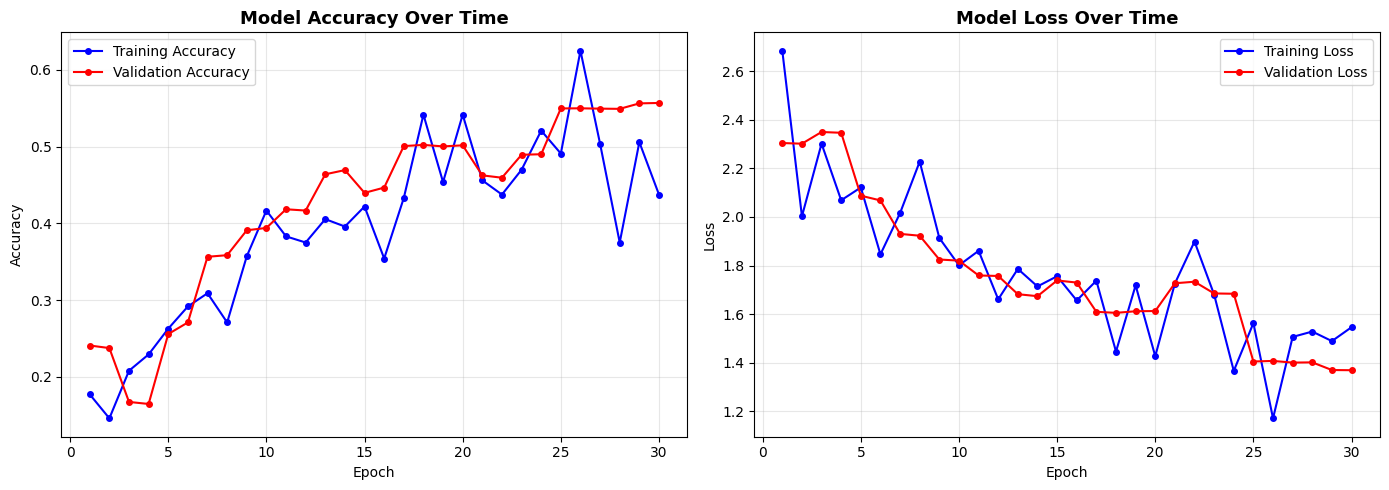


📊 Training Summary
───────────────────────────────────
  Total epochs ran    : 30
  Best epoch          : 30
  Best val accuracy   : 0.5569 (55.69%)
  Final train accuracy: 0.4375 (43.75%)


In [ ]:
def plot_training_history(history):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs_ran = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Accuracy Plot ─────────────────────────────────────────
    axes[0].plot(epochs_ran, acc,     'b-o', label='Training Accuracy',   markersize=4)
    axes[0].plot(epochs_ran, val_acc, 'r-o', label='Validation Accuracy', markersize=4)
    axes[0].set_title('Model Accuracy Over Time', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Loss Plot ─────────────────────────────────────────────
    axes[1].plot(epochs_ran, loss,     'b-o', label='Training Loss',   markersize=4)
    axes[1].plot(epochs_ran, val_loss, 'r-o', label='Validation Loss', markersize=4)
    axes[1].set_title('Model Loss Over Time', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig('results/training_curves.png', dpi=150)
    plt.show()

    # ── Summary ───────────────────────────────────────────────
    best_epoch   = val_acc.index(max(val_acc)) + 1
    best_val_acc = max(val_acc)
    print(f"\n📊 Training Summary")
    print(f"{'─'*35}")
    print(f"  Total epochs ran    : {len(acc)}")
    print(f"  Best epoch          : {best_epoch}")
    print(f"  Best val accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"  Final train accuracy: {acc[-1]:.4f} ({acc[-1]*100:.2f}%)")

plot_training_history(history)

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_emotion_model.h5')

print("✅ Best model loaded!")

test_loss , test_acc = best_model.evaluate(test_generator , verbose = 1)
print(f"\n🎯 Final Test Accuracy : {test_acc*100:.2f}%")
print(f"   Final Test Loss     : {test_loss:.4f}")

✅ Best model loaded!
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5577 - loss: 1.3679

🎯 Final Test Accuracy : 55.77%
   Final Test Loss     : 1.3679


150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


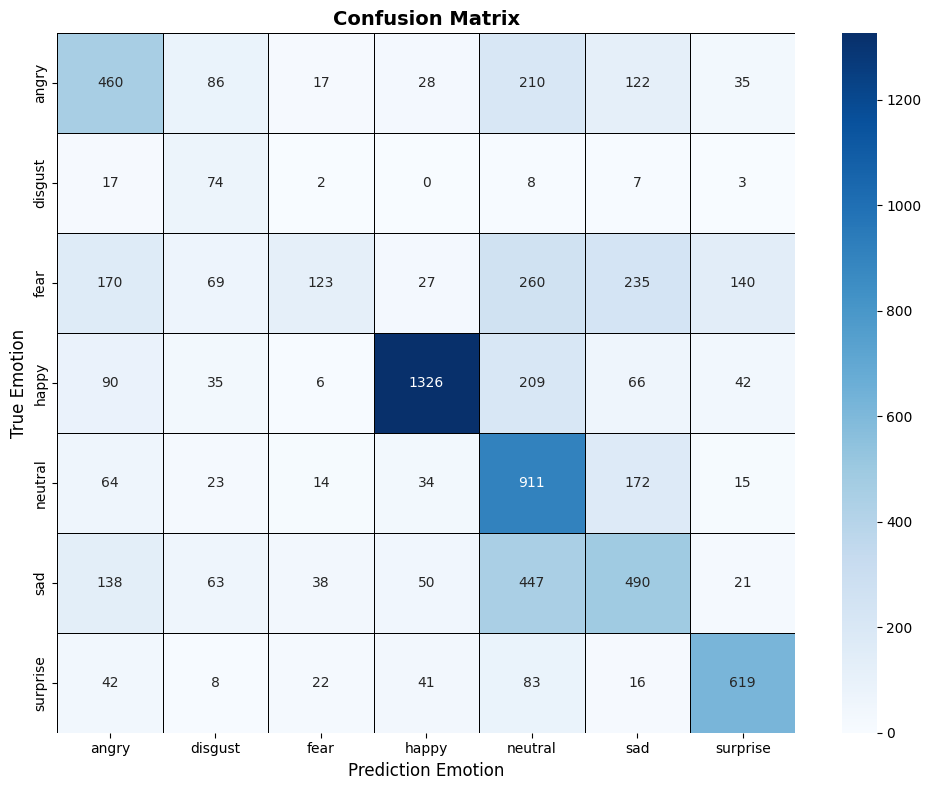


Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       angry       0.47      0.48      0.47       958
     disgust       0.21      0.67      0.32       111
        fear       0.55      0.12      0.20      1024
       happy       0.88      0.75      0.81      1774
     neutral       0.43      0.74      0.54      1233
         sad       0.44      0.39      0.42      1247
    surprise       0.71      0.74      0.73       831

    accuracy                           0.56      7178
   macro avg       0.53      0.56      0.50      7178
weighted avg       0.59      0.56      0.55      7178



In [ ]:
from sklearn.metrics import confusion_matrix , classification_report

test_generator.reset()
predictions = best_model.predict(test_generator , verbose = 1)

predicated_classes = np.argmax(predictions , axis = 1)


true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(true_classes , predicated_classes)


plt.figure(figsize = (10 , 8))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths = 0.5,
    linecolor = 'black'
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()
#plt.savefig('results/confusion_matrix.png' , dpi = 150)
plt.show()

# ── Per-class Report ─────────────────────────────────────────

print("\nClassification Report:")
print("-" * 60)
print(classification_report(true_classes , predicated_classes , target_names = class_names))


In [ ]:
'''
# Save the final model in two formats
best_model.save('results/emotion_model_final.h5')
# .h5 = full model (architecture + weights) in one file

# Also save just the weights separately
best_model.save_weights('results/emotion_model_weights.h5')

# Save the class names mapping — you'll need this in the webcam demo
import json
class_mapping = train_generator.class_indices
with open('results/class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("✅ Saved:")
print("  - emotion_model_final.h5")
print("  - emotion_model_weights.h5")
print("  - class_mapping.json")
print("\n📁 results/ folder is ready to push to GitHub!")

SyntaxError: incomplete input (1559710867.py, line 1)

In [ ]:
from IPython.display import display
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
from PIL import Image
import io

def capture_photo():
    # Pass JavaScript as a plain string — NOT wrapped in Javascript()
    js_code = """
        (async () => {
            const div = document.createElement('div');
            div.style.cssText = 'position:fixed;top:0;left:0;width:100%;height:100%;background:rgba(0,0,0,0.8);z-index:9999;display:flex;flex-direction:column;align-items:center;justify-content:center;';

            const video = document.createElement('video');
            video.style.cssText = 'width:400px;border-radius:12px;';
            video.autoplay = true;

            const btn = document.createElement('button');
            btn.textContent = 'Take Photo';
            btn.style.cssText = 'margin-top:20px;padding:12px 32px;font-size:16px;background:#4CAF50;color:white;border:none;border-radius:8px;cursor:pointer;';

            div.appendChild(video);
            div.appendChild(btn);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;

            await new Promise(resolve => btn.addEventListener('click', resolve));

            const canvas = document.createElement('canvas');
            canvas.width  = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(t => t.stop());
            document.body.removeChild(div);

            return canvas.toDataURL('image/jpeg', 0.85);
        })()
    """

    # eval_js takes a plain string — this is the fix
    data   = eval_js(js_code)
    binary = b64decode(data.split(',')[1])
    image  = Image.open(io.BytesIO(binary))
    return np.array(image)

print("📸 A camera preview will appear — click 'Take Photo' when ready")
photo = capture_photo()
print(f"✅ Photo captured! Shape: {photo.shape}")

📸 A camera preview will appear — click 'Take Photo' when ready


MessageError: NotFoundError: Requested device not found

In [ ]:
from tensorflow.keras.models import load_model
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

best_model = load_model('best_emotion_model.h5')

# Ensure the 'results' directory exists
os.makedirs('results', exist_ok=True)

try:
    with open('results/class_mapping.json', 'r') as f:
        class_mapping = json.load(f)
except FileNotFoundError:
    print("⚠️  class_mapping.json not found, creating it from train_generator.class_indices.")
    # Assuming train_generator is available in the global scope from previous cells
    if 'train_generator' in globals():
        class_mapping = train_generator.class_indices
        with open('results/class_mapping.json', 'w') as f:
            json.dump(class_mapping, f, indent=2)
    else:
        raise ValueError("train_generator not found. Cannot create class_mapping.json.")

idx_to_emotion = {v: k for k, v in class_mapping.items()}


emotion_emoji = {
    'angry'   : '😠', 'disgust': '🤢', 'fear'   : '😨',
    'happy'   : '😄', 'neutral': '😐', 'sad'    : '😢',
    'surprise': '😮'
}

# ── Load face detector ────────────────────────────────────────
# OpenCV's pre-built face detector — uses a different AI technique
# called Haar Cascades (fast, works well for frontal faces)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def preprocess_face(face_img, img_size=48): # Changed default img_size to 48 (IMG_SIZE)
    # Convert to grayscale
    face_gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    # Resize
    face_resized = cv2.resize(face_gray, (img_size, img_size))
    # Normalize
    face_normalized = face_resized / 255.0
    # Add channel dimension (1 for grayscale)
    face_with_channel = np.expand_dims(face_normalized, axis=-1)
    # Add batch dimension
    face_batch = np.expand_dims(face_with_channel, axis=0)
    return face_batch

def predict_emotion(photo):
  """
  1. Convert to grayscale for face detection
  2. Find face with Haar Cascade
  3. Crop face, preprocess, run model
  4. Return annotated image
  """

  img_bgr  = cv2.cvtColor(photo, cv2.COLOR_RGB2BGR)
  img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


  faces = face_cascade.detectMultiScale(
        img_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(48, 48)
  )
  result_img = img_bgr.copy()

  if len(faces) == 0:
      print("⚠️  No face detected — try better lighting or move closer")
      return photo, None

  for (x, y, w, h) in faces:
      # add some padding around the face
      pad = int(0.1 * w)
      x1 = max(0, x - pad)
      y1 = max(0, y - pad)
      x2 = min(img_bgr.shape[1], x + w + pad)
      y2 = min(img_bgr.shape[0], y + h + pad)

      # crop and preprocess
      face_crop  = img_bgr[y1:y2, x1:x2]
      face_input = preprocess_face(face_crop)

      # predict
      predictions = best_model.predict(face_input, verbose=0)[0]
      emotion_idx = np.argmax(predictions)
      emotion     = idx_to_emotion[emotion_idx]
      confidence  = predictions[emotion_idx] * 100
      emoji       = emotion_emoji[emotion]

      # ── Draw on image ─────────────────────────────────────
      color = (0, 255, 0)  # green box
      cv2.rectangle(result_img, (x1, y1), (x2, y2), color, 2)

      label = f"{emoji} {emotion.upper()}  {confidence:.1f}%"
      (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

      # background rectangle for text
      cv2.rectangle(result_img,
                    (x1, y1 - th - 12),
                    (x1 + tw + 8, y1),
                    color, -1)

      cv2.putText(result_img, label,
                  (x1 + 4, y1 - 6),
                  cv2.FONT_HERSHEY_SIMPLEX,
                  0.8, (0, 0, 0), 2)

      # ── Print all probabilities ────────────────────────────
      print(f"\n🎯 Detected: {emoji} {emotion.upper()} ({confidence:.1f}% confident)\n")
      print("  All probabilities:")
      for i, prob in enumerate(predictions):
          bar = '█' * int(prob * 20)
          em  = idx_to_emotion[i]
          print(f"  {em:10s} {bar:<20s} {prob*100:.1f}%")

  result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
  return result_rgb, emotion

# ── Run it ────────────────────────────────────────────────────
result_image, detected_emotion = predict_emotion(photo)

plt.figure(figsize=(8, 6))
plt.imshow(result_image)
plt.axis('off')
plt.title('Emotion Detection Result', fontsize=14, fontweight='bold')
plt.savefig('results/demo_result.png', dpi=150)
plt.show()

⚠️  class_mapping.json not found, creating it from train_generator.class_indices.


NameError: name 'photo' is not defined